In [2]:
import requests
import pandas as pd

## Data Collection
Weather data for Adana, Turkey (lat: 37.0, lon: 35.3) is retrieved from the 
Open-Meteo Archive API. The dataset covers 2023–2026 and includes daily mean 
temperature, relative humidity, wind speed, and surface pressure.

In [3]:
url = "https://archive-api.open-meteo.com/v1/archive?latitude=37.0&longitude=35.3&start_date=2023-01-01&end_date=2026-04-15&daily=temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_mean,surface_pressure_mean&timezone=auto"

response = requests.get(url)
data = response.json()

df = pd.DataFrame({
    "date": data["daily"]["time"],
    "meantemp": data["daily"]["temperature_2m_mean"],
    "humidity": data["daily"]["relative_humidity_2m_mean"],
    "wind_speed": data["daily"]["wind_speed_10m_mean"],
    "meanpressure": data["daily"]["surface_pressure_mean"]
})

print(df.head())

         date  meantemp  humidity  wind_speed  meanpressure
0  2023-01-01      10.9        52         8.2        1025.9
1  2023-01-02      10.9        47         7.0        1025.0
2  2023-01-03      10.9        43         7.8        1023.1
3  2023-01-04       9.8        47         7.3        1017.4
4  2023-01-05       9.9        60         8.4        1015.6


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1201 entries, 0 to 1200
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1201 non-null   object 
 1   meantemp      1201 non-null   float64
 2   humidity      1201 non-null   int64  
 3   wind_speed    1201 non-null   float64
 4   meanpressure  1201 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 47.0+ KB


## Exploratory Data Analysis
We visualize the temporal trends of each weather variable and examine the 
relationship between temperature and humidity using a scatter plot with an OLS trendline.

In [5]:
import plotly.express as px
figure = px.line(df, x="date", 
                 y="meantemp", 
                 title='Mean Temperature in Adana Over the Years')
figure.show()

In [6]:
figure = px.line(df, x="date", 
                 y="humidity", 
                 title='Humidity in Adana Over the Years')
figure.show()

In [7]:
figure = px.line(df, x="date", 
                 y="wind_speed", 
                 title='Wind Speed in Adana Over the Years')
figure.show()

In [8]:
figure = px.scatter(data_frame = df, x="humidity",
                    y="meantemp", size="meantemp", 
                    trendline="ols", 
                    title = "Relationship Between Temperature and Humidity")
figure.show()

In [9]:
df["date"] = pd.to_datetime(df["date"], format = '%Y-%m-%d')
df['year'] = df['date'].dt.year
df["month"] = df["date"].dt.month
print(df.head())

        date  meantemp  humidity  wind_speed  meanpressure  year  month
0 2023-01-01      10.9        52         8.2        1025.9  2023      1
1 2023-01-02      10.9        47         7.0        1025.0  2023      1
2 2023-01-03      10.9        43         7.8        1023.1  2023      1
3 2023-01-04       9.8        47         7.3        1017.4  2023      1
4 2023-01-05       9.9        60         8.4        1015.6  2023      1


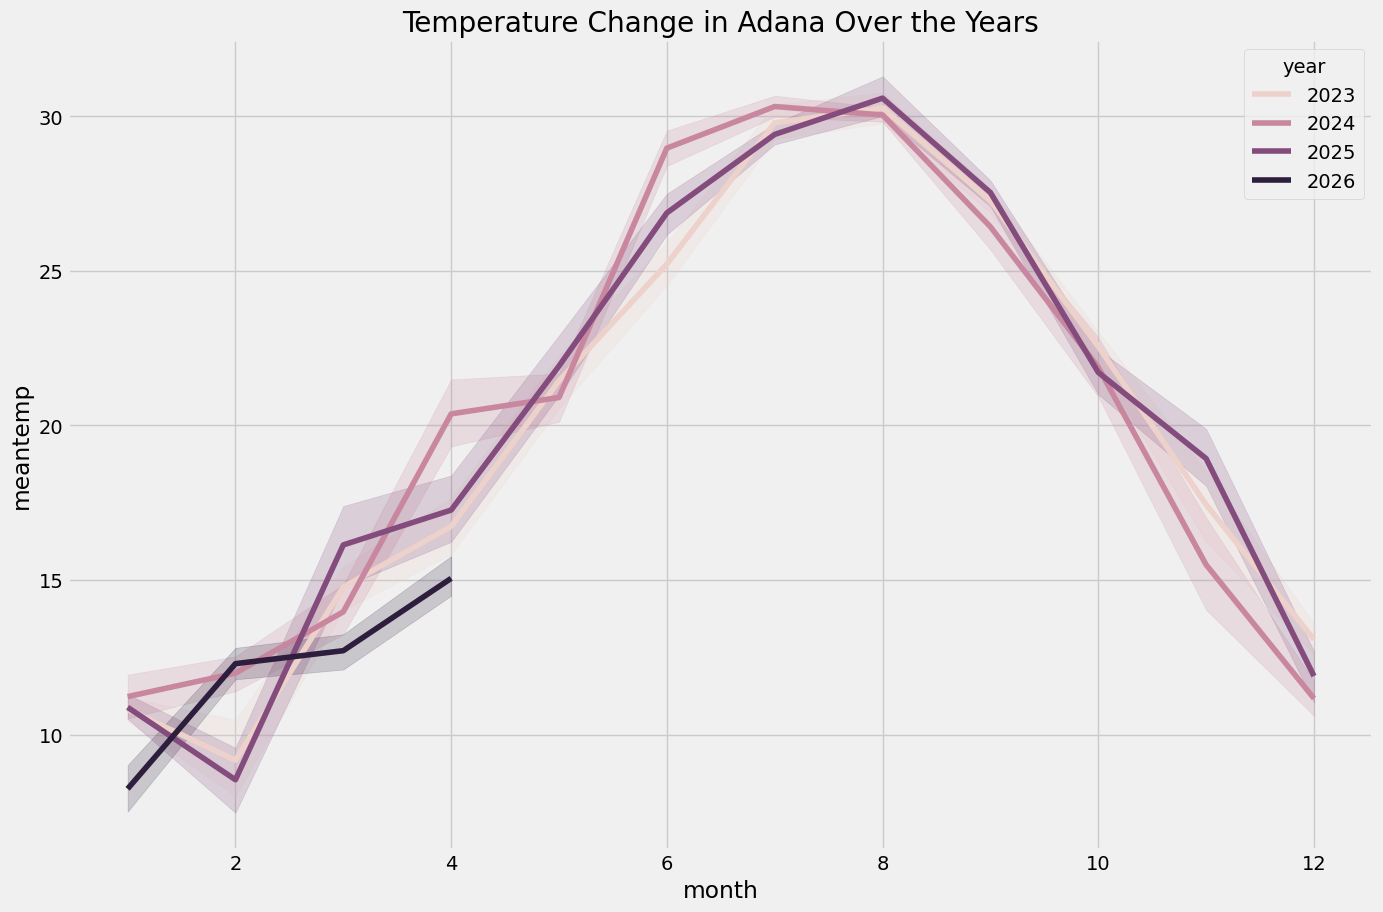

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
plt.figure(figsize=(15, 10))
plt.title("Temperature Change in Adana Over the Years")
sns.lineplot(data = df, x='month', y='meantemp', hue='year')
plt.show()

## Forecasting with Prophet
Facebook's Prophet library is used for time series forecasting. The model 
captures yearly and weekly seasonality patterns to generate a 365-day forecast.

In [11]:
forecast_data = df.rename(columns={"date": "ds", "meantemp": "y"}).dropna()
print(forecast_data)

             ds     y  humidity  wind_speed  meanpressure  year  month
0    2023-01-01  10.9        52         8.2        1025.9  2023      1
1    2023-01-02  10.9        47         7.0        1025.0  2023      1
2    2023-01-03  10.9        43         7.8        1023.1  2023      1
3    2023-01-04   9.8        47         7.3        1017.4  2023      1
4    2023-01-05   9.9        60         8.4        1015.6  2023      1
...         ...   ...       ...         ...           ...   ...    ...
1196 2026-04-11  14.0        72         7.5        1011.0  2026      4
1197 2026-04-12  13.7        68         5.2        1011.2  2026      4
1198 2026-04-13  13.9        62         7.3        1014.5  2026      4
1199 2026-04-14  15.5        67         5.4        1018.7  2026      4
1200 2026-04-15  19.4        66         5.9        1014.1  2026      4

[1201 rows x 7 columns]


## Forecasting with Prophet
Facebook's Prophet library is used for time series forecasting.
The model captures yearly and weekly seasonality patterns to generate a 365-day forecast.

In [12]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly
model = Prophet()
model.fit(forecast_data)
forecasts = model.make_future_dataframe(periods=365)
predictions = model.predict(forecasts)
plot_plotly(model, predictions)

19:17:26 - cmdstanpy - INFO - Chain [1] start processing
19:17:26 - cmdstanpy - INFO - Chain [1] done processing


## Model Evaluation
We use Prophet's built-in cross-validation to assess forecast accuracy.
MAE and RMSE measure absolute error in °C; MAPE reflects relative error.

In [13]:
from prophet.diagnostics import cross_validation, performance_metrics

# Cross-validation: son 180 günü test seti olarak değerlendirir
df_cv = cross_validation(
    model,
    initial='730 days',   # eğitim için kullanılan başlangıç penceresi
    period='90 days',     # her seferinde kaç gün kaydırılacak
    horizon='180 days'    # kaç gün ileriye tahmin edilecek
)

# Performans metrikleri
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'mae', 'rmse', 'mape']].head(10))

  0%|          | 0/4 [00:00<?, ?it/s]

19:17:28 - cmdstanpy - INFO - Chain [1] start processing
19:17:28 - cmdstanpy - INFO - Chain [1] done processing
19:17:28 - cmdstanpy - INFO - Chain [1] start processing
19:17:28 - cmdstanpy - INFO - Chain [1] done processing
19:17:28 - cmdstanpy - INFO - Chain [1] start processing
19:17:29 - cmdstanpy - INFO - Chain [1] done processing
19:17:29 - cmdstanpy - INFO - Chain [1] start processing
19:17:29 - cmdstanpy - INFO - Chain [1] done processing


  horizon       mae      rmse      mape
0 18 days  1.179412  1.694386  0.077500
1 19 days  1.259381  1.770888  0.081906
2 20 days  1.363313  1.904431  0.086800
3 21 days  1.487287  2.043964  0.092515
4 22 days  1.629222  2.178276  0.098742
5 23 days  1.678981  2.216774  0.100425
6 24 days  1.700912  2.253009  0.100422
7 25 days  1.713677  2.275355  0.100098
8 26 days  1.754515  2.316403  0.100565
9 27 days  1.828375  2.394616  0.103101


## Summary

Weather forecasting is the task of forecasting weather conditions for a given location and time. With the use of weather data and algorithms, it is possible to predict weather conditions for the next n number of days.